## Calibration by temparature scaling

### Imports

In [ ]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from datasets import load_dataset
from tqdm import tqdm

sys.path.append("../services/")
from index import Index, IndexDataset
from metric_funcs import calculate_ece_adaptive_bins
from process_funcs import retrieve_answer_token_index

/home/nikita/proga/Diplom/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Preparation

In [3]:
torch.random.manual_seed(42)

dataset = load_dataset("TIGER-Lab/MMLU-Pro", split="test").select(range(12000))
index = Index("../index_data/qwen2.5-7B_MMLU-PRO_launch_12000")

In [4]:
PAD_VAL = 0

VOCAB_SIZE = 20
split_val = len(index) // 2


def process_elements(xs: np.array, ys: np.array):
    processed = {}

    allowed_ids = []
    for i, x in enumerate(xs):
        # Ignoring responses where answer token distribution doesn't have all 0-9 tokens
        log = x["logprobs"][retrieve_answer_token_index(x["logprobs"])]
        if (
            len(
                set([str(x) for x in range(10)]).intersection(
                    set([x["token"] for x in log["top_logprobs"]])
                )
            )
            < 10
        ):
            continue
        allowed_ids.append(i)

    xs = xs[allowed_ids]
    ys = ys[allowed_ids]

    logits = torch.zeros((len(xs), VOCAB_SIZE))
    targets = torch.zeros(len(ys), dtype=torch.long)

    for i, (x, y) in enumerate(zip(xs, ys)):
        answer_token_index = retrieve_answer_token_index(x["logprobs"])
        answer_top_logprobs_tokens = [
            v["token"]
            for v in x["logprobs"][answer_token_index]["top_logprobs"]
        ]
        answer_top_logprobs = torch.tensor(
            [
                v["logprob"]
                for v in x["logprobs"][answer_token_index]["top_logprobs"]
            ]
        )

        max_logprob = answer_top_logprobs.max()
        norm_top_logprobs = answer_top_logprobs - max_logprob

        logits[i] = norm_top_logprobs
        targets[i] = torch.tensor(
            answer_top_logprobs_tokens.index(str(y["answer_index"])),
            dtype=torch.long,
        )

    processed["logits"] = logits
    processed["targets"] = targets

    return processed

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train = IndexDataset(
    index, dataset, process_elements, split="train", load_all_data=True
)
val = IndexDataset(
    index, dataset, process_elements, split="val", load_all_data=True
)
test = IndexDataset(
    index, dataset, process_elements, split="test", load_all_data=True
)

In [6]:
val_data = val.get()
test_data = test.get()

### Temperature scaling

In [7]:
# Module which will learn temperature value


class TemperatureScaling(nn.Module):
    def __init__(self, device=device):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1, device=device))

    def forward(self, logits):
        return torch.div(logits, self.temperature)

    def calibrate(self, logits):
        self.eval()
        with torch.no_grad():
            self.forward(logits)

In [8]:
# Function to fit temperature value


def fit_temperature_scaling(
    train_data,
    test_data=None,
    lr_max=1e-2,
    lr_min=1e-4,
    batch_size=8,
    epochs=3,
    plot_interval=3,
):
    temperature_model = TemperatureScaling(device)
    optimizer = torch.optim.Adam([temperature_model.temperature], lr_max)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, len(train_data) // batch_size, lr_min
    )

    train_losses = []
    test_losses = []
    iterations = []

    iteration_counter = 0

    for _ in tqdm(range(epochs)):
        for start in range(0, len(train_data) - batch_size, batch_size):
            batch_data = train_data.get(start, start + batch_size)
            if not batch_data:
                continue

            optimizer.zero_grad()
            batch_logits = batch_data["logits"].view(-1, VOCAB_SIZE).to(device)
            batch_labels = batch_data["targets"].view(-1).to(device)
            train_scaled_logits = temperature_model(batch_logits)
            train_loss = torch.nn.functional.cross_entropy(
                train_scaled_logits, batch_labels
            )
            train_loss.backward()
            optimizer.step()
            scheduler.step()

            if (
                test_data is not None
                and iteration_counter % plot_interval == 0
            ):
                train_loss = train_loss.item()
                train_losses.append(train_loss)

                test_batch = test_data.get(0, min(batch_size, len(test_data)))
                if test_batch:
                    test_logits = (
                        test_batch["logits"].view(-1, VOCAB_SIZE).to(device)
                    )
                    test_labels = test_batch["targets"].view(-1).to(device)
                    with torch.no_grad():
                        test_scaled_logits = temperature_model(test_logits)
                        test_loss = torch.nn.functional.cross_entropy(
                            test_scaled_logits, test_labels
                        )
                        test_losses.append(test_loss.item())
                    iterations.append(iteration_counter)

            iteration_counter += 1

    if len(iterations) > 0:
        plt.figure(figsize=(10, 6))
        plt.plot(iterations, train_losses, label="Train Loss", marker="o")
        if len(test_losses) > 0:
            plt.plot(iterations, test_losses, label="Test Loss", marker="s")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss over Iterations")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return temperature_model.temperature.item()

## Calibration

### FInding the best temperature on validation data


Trial 1/10: lr_max=0.005000, lr_min=0.000500, batch_size=16, epochs=3


100%|██████████| 3/3 [00:03<00:00,  1.24s/it]


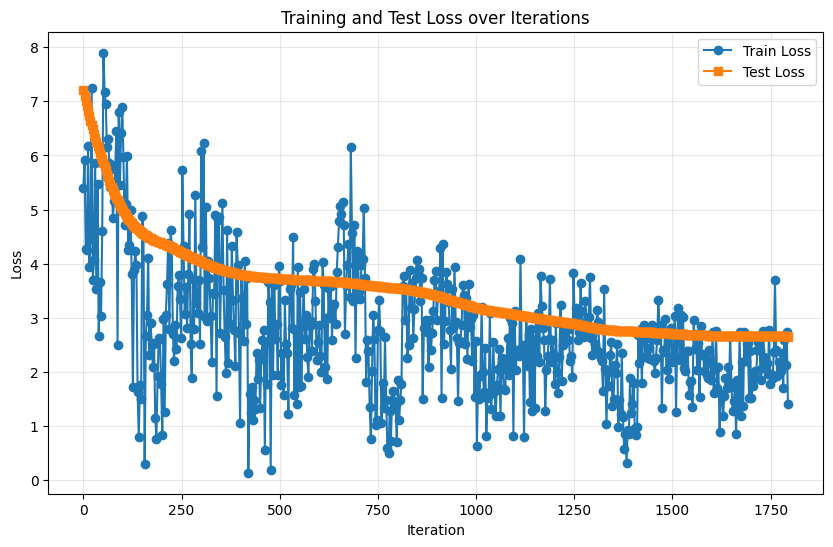

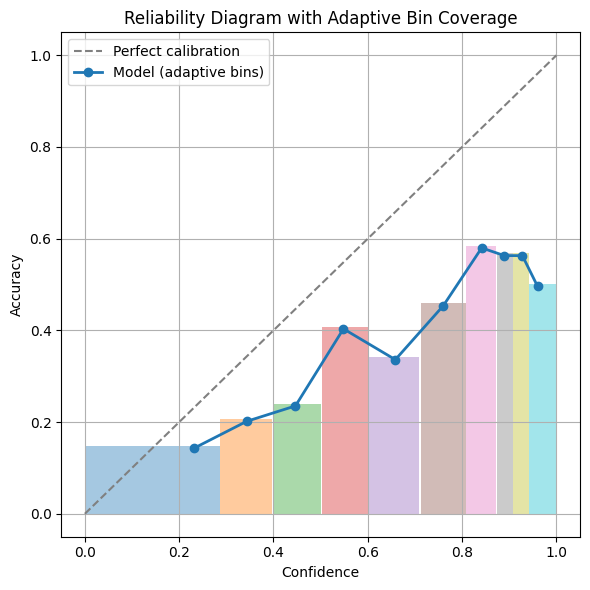

Temperature: 3.3286, ECE: 0.264531

Trial 2/10: lr_max=0.005000, lr_min=0.001000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.09it/s]


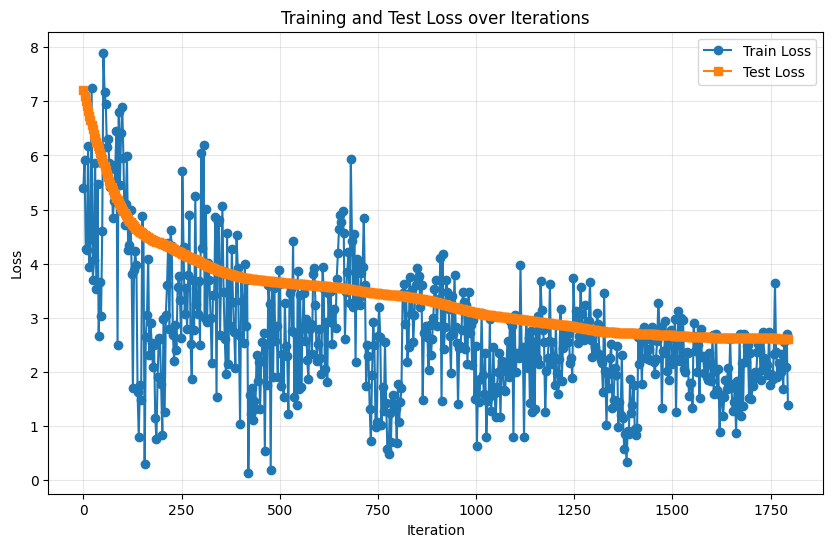

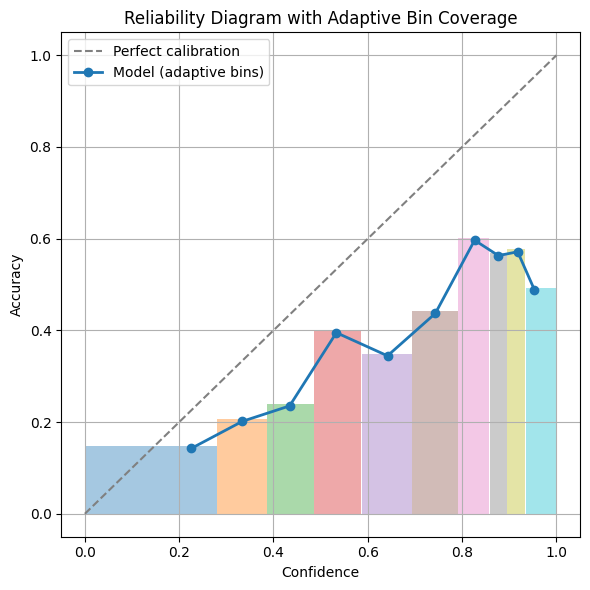

Temperature: 3.4279, ECE: 0.252620

Trial 3/10: lr_max=0.050000, lr_min=0.001000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.06it/s]


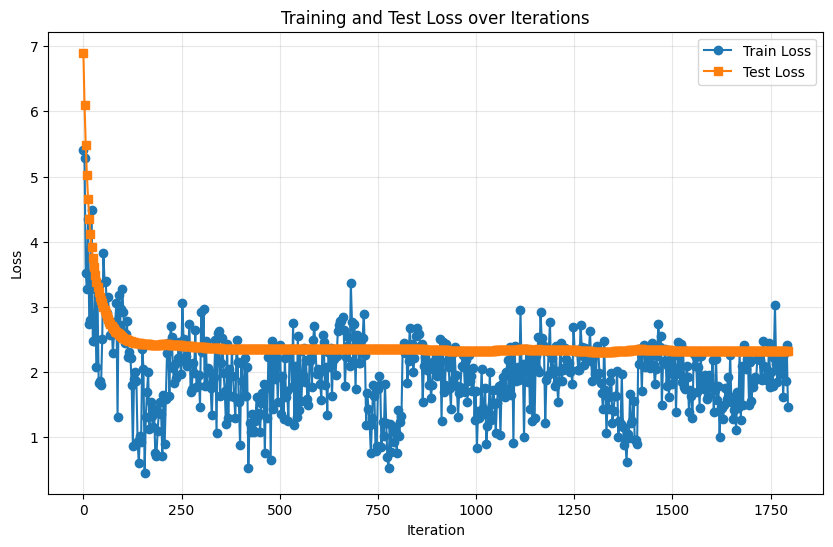

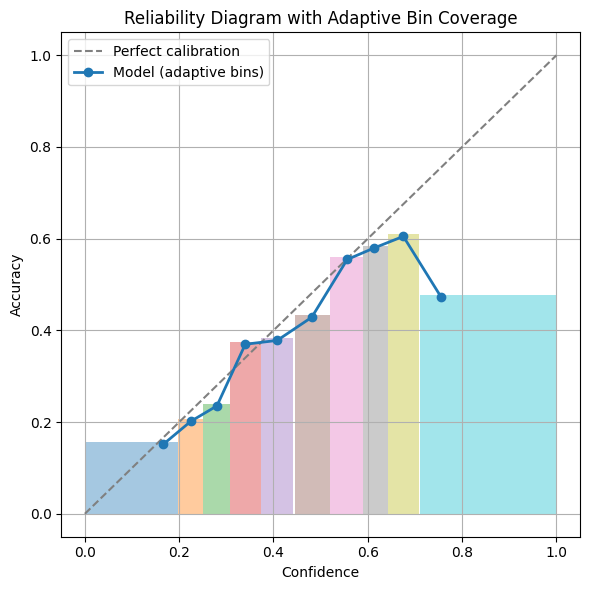

Temperature: 5.2117, ECE: 0.059840

Trial 4/10: lr_max=0.005000, lr_min=0.000500, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.10it/s]


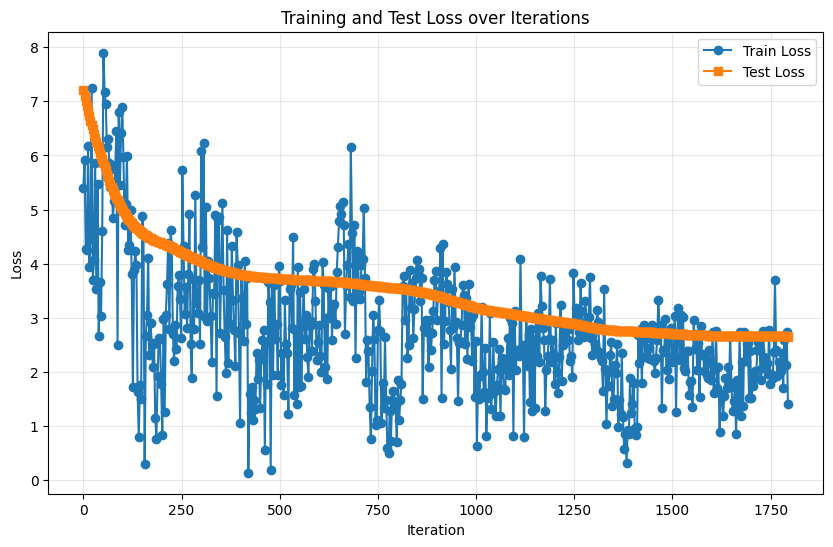

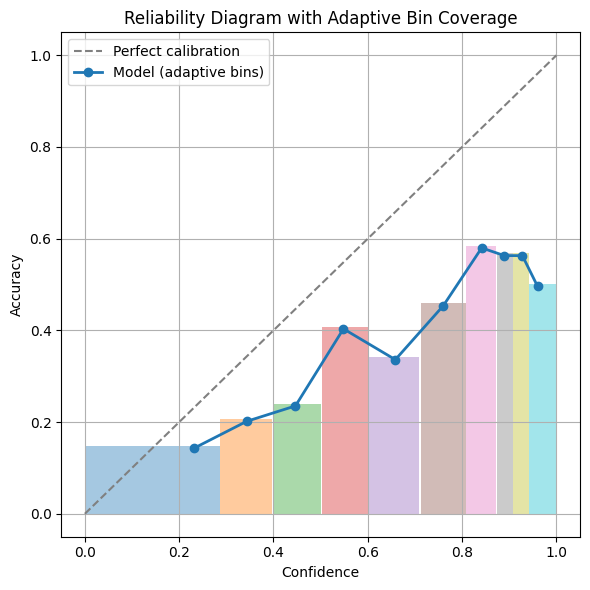

Temperature: 3.3286, ECE: 0.264531

Trial 5/10: lr_max=0.005000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.07it/s]


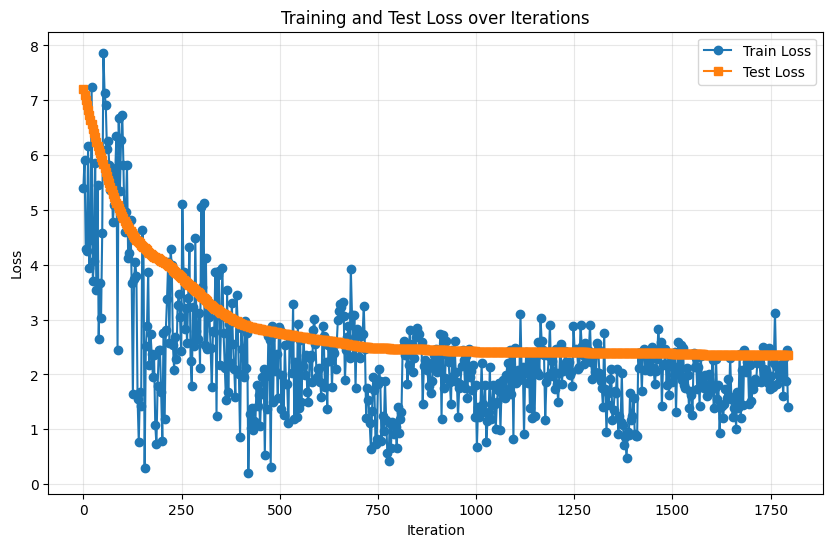

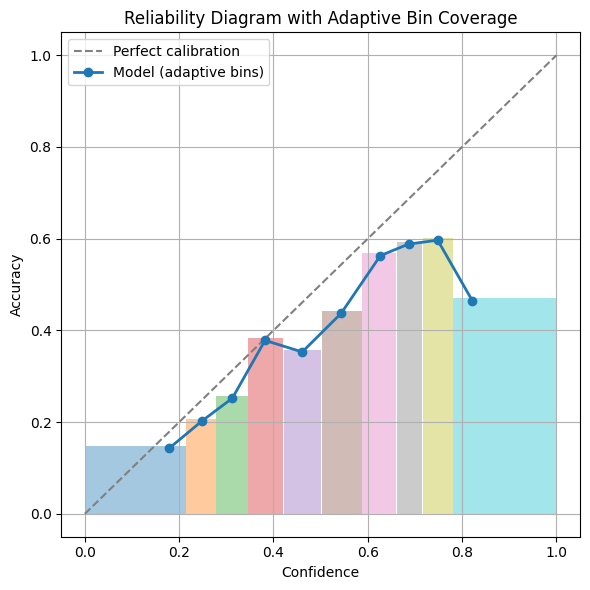

Temperature: 4.7082, ECE: 0.104828

Trial 6/10: lr_max=0.050000, lr_min=0.000100, batch_size=16, epochs=3


100%|██████████| 3/3 [00:04<00:00,  1.64s/it]


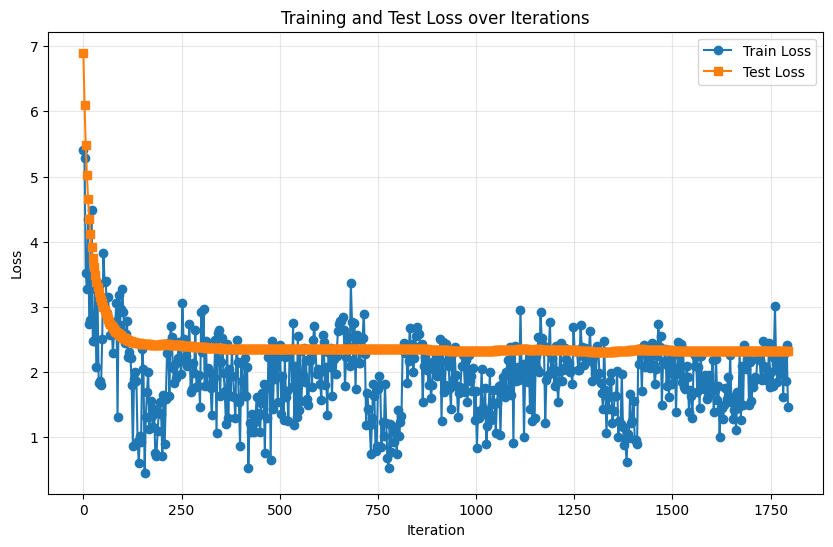

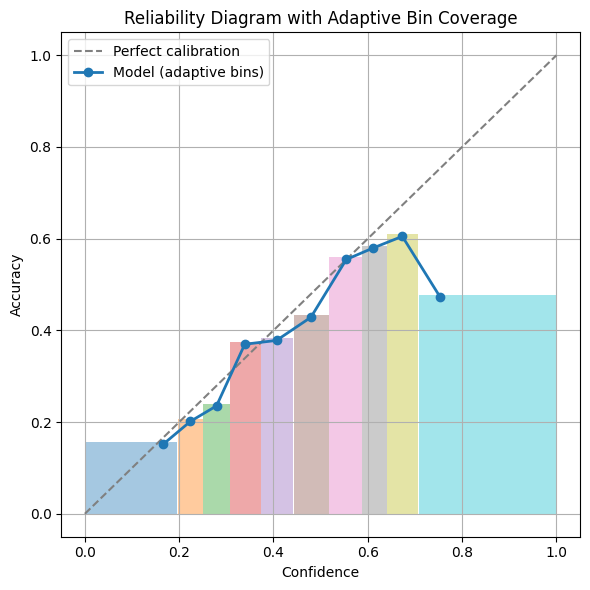

Temperature: 5.2269, ECE: 0.058670

Trial 7/10: lr_max=0.100000, lr_min=0.000500, batch_size=16, epochs=3


100%|██████████| 3/3 [00:03<00:00,  1.16s/it]


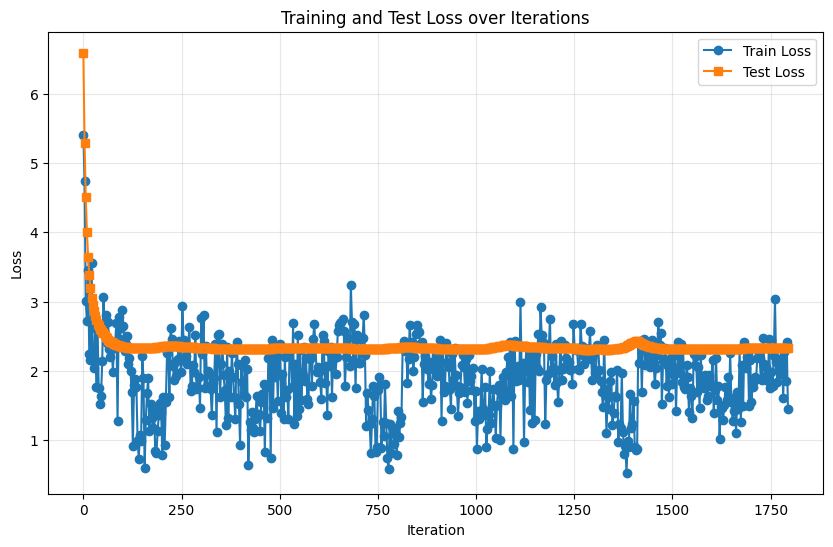

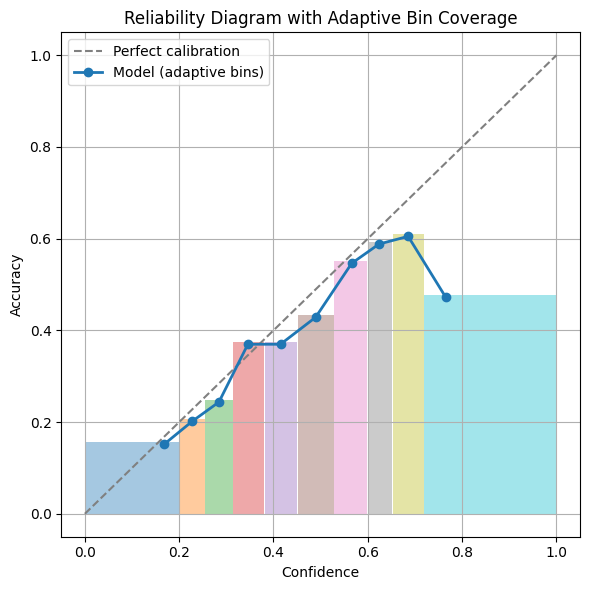

Temperature: 5.1399, ECE: 0.065660

Trial 8/10: lr_max=0.005000, lr_min=0.000500, batch_size=16, epochs=3


100%|██████████| 3/3 [00:03<00:00,  1.20s/it]


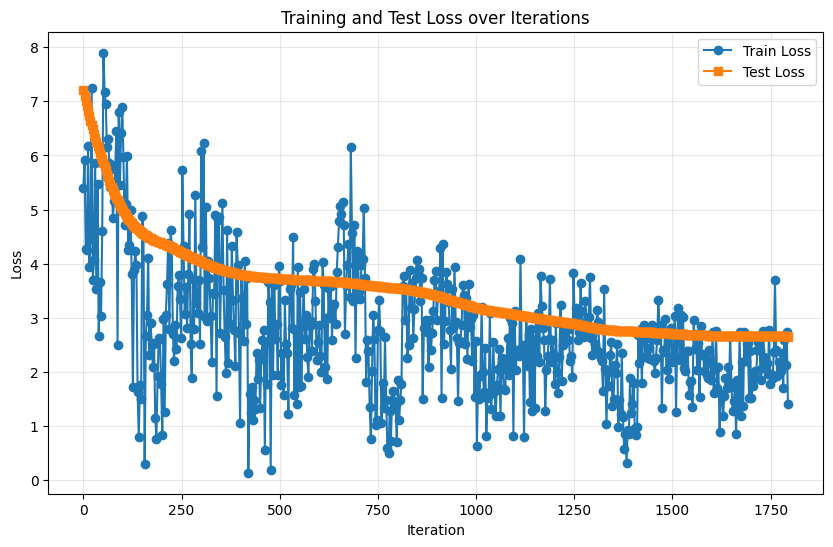

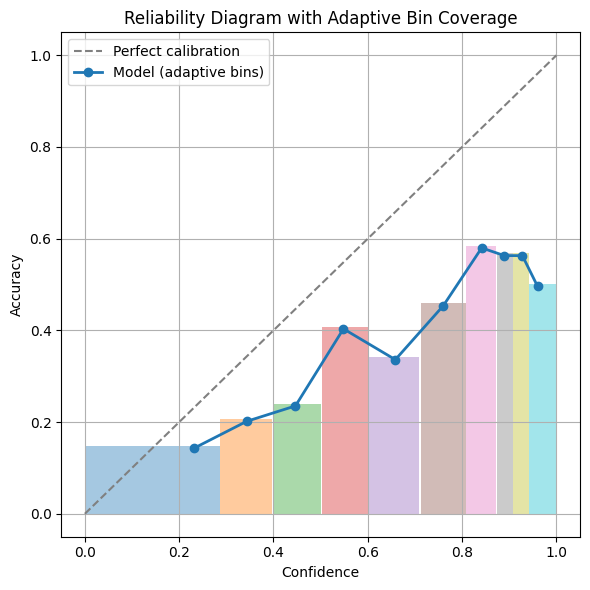

Temperature: 3.3286, ECE: 0.264531

Trial 9/10: lr_max=0.001000, lr_min=0.000500, batch_size=16, epochs=3


100%|██████████| 3/3 [00:03<00:00,  1.12s/it]


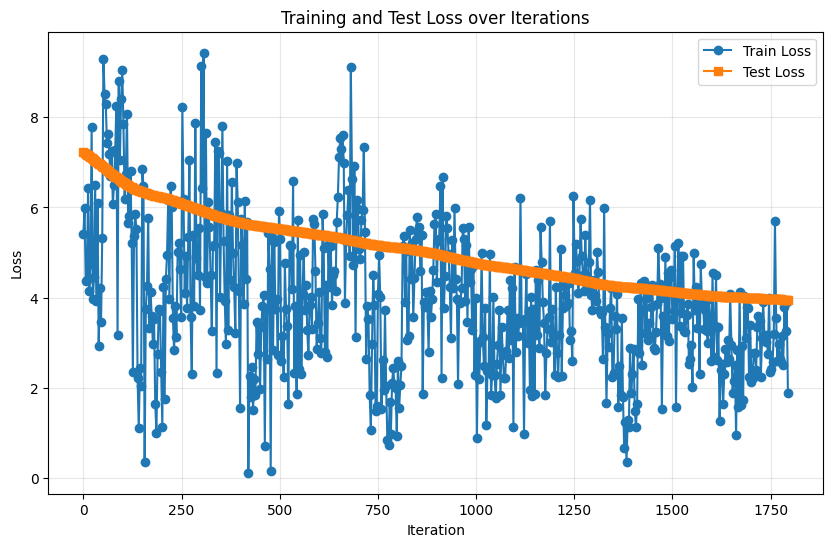

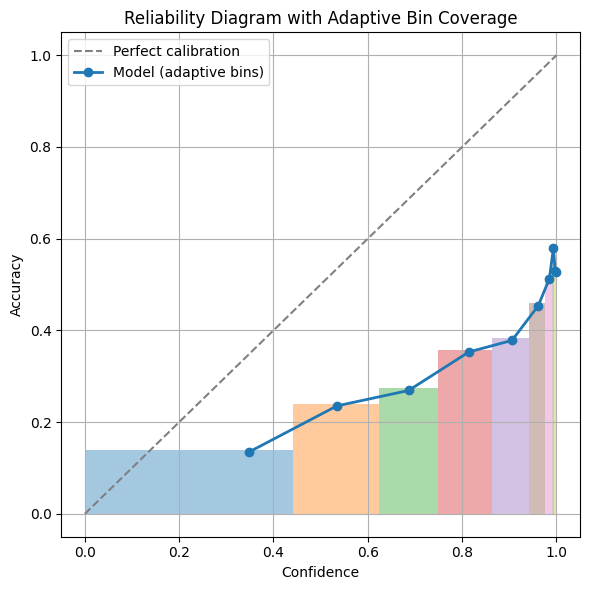

Temperature: 1.9065, ECE: 0.425535

Trial 10/10: lr_max=0.001000, lr_min=0.020000, batch_size=16, epochs=3


100%|██████████| 3/3 [00:02<00:00,  1.26it/s]


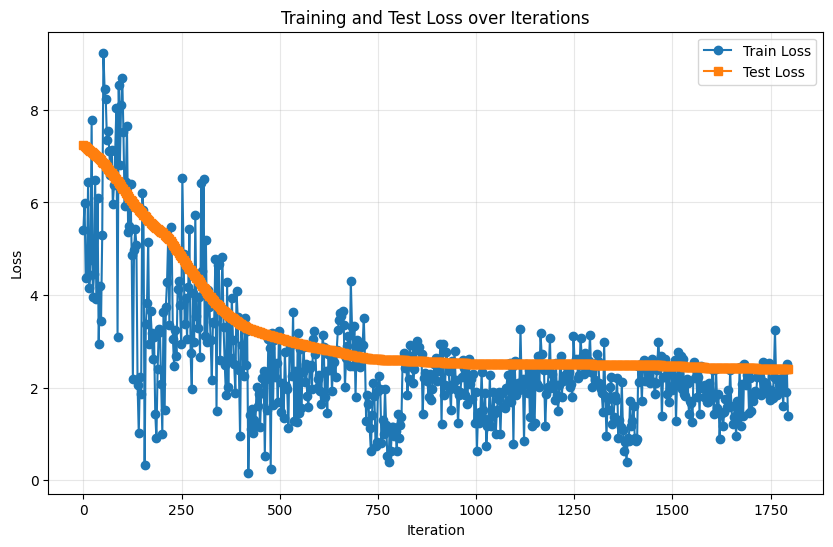

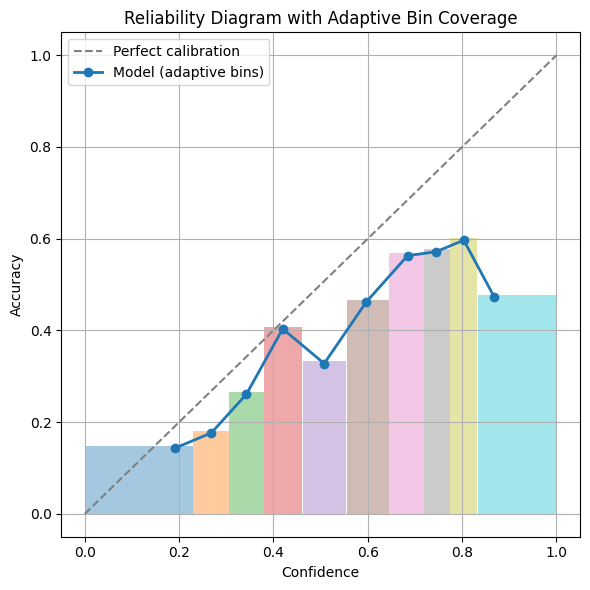

Temperature: 4.3281, ECE: 0.146576

Best ECE on: 0.058670
Best parameters: {'lr_max': np.float64(0.05), 'lr_min': np.float64(0.0001), 'batch_size': 16, 'epochs': 3}
Best temperature: 5.2269


In [10]:
TRIALS = 10

results = []

for trial in range(TRIALS):
    lr_max = np.random.choice([1e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1])
    lr_min = np.random.choice([1e-4, 5e-4, 1e-3, 2e-2])
    batch_size = 16
    epochs = 3

    print(
        f"\nTrial {trial + 1}/{TRIALS}: lr_max={lr_max:.6f}, lr_min={lr_min:.6f}, batch_size={batch_size}, epochs={epochs}"
    )

    temperature = fit_temperature_scaling(
        train,
        val,
        lr_max=lr_max,
        lr_min=lr_min,
        batch_size=batch_size,
        epochs=epochs,
    )

    calibrated_logits = [torch.div(x, temperature) for x in val_data["logits"]]
    calibrated_probs = torch.stack(
        [torch.softmax(x, dim=0) for x in calibrated_logits]
    )
    ece = calculate_ece_adaptive_bins(
        calibrated_probs, val_data["targets"], verbose=True
    )

    results.append(
        {
            "params": {
                "lr_max": lr_max,
                "lr_min": lr_min,
                "batch_size": batch_size,
                "epochs": epochs,
            },
            "temperature": temperature,
            "ece": ece,
        }
    )

    print(f"Temperature: {temperature:.4f}, ECE: {ece:.6f}")

best_result = min(results, key=lambda x: x["ece"])

print("\n" + "=" * 60)
print(f"Best ECE on: {best_result['ece']:.6f}")
print(f"Best parameters: {best_result['params']}")
print(f"Best temperature: {best_result['temperature']:.4f}")

### Results

In [11]:
temperature = best_result["temperature"]

calibrated_test_answers_logits = [
    torch.div(x, temperature) for x in test_data["logits"]
]

not_calibrated_test_answers_probs = torch.stack(
    [torch.softmax(x, dim=0) for x in test_data["logits"]]
)
calibrated_test_answers_probs = torch.stack(
    [torch.softmax(x, dim=0) for x in calibrated_test_answers_logits]
)

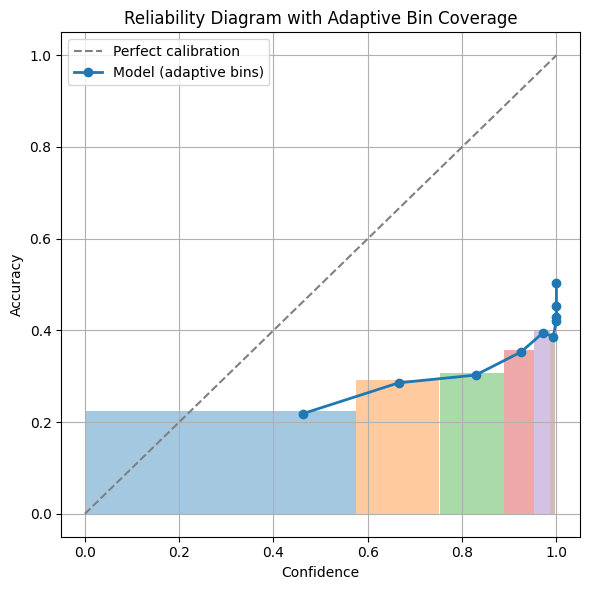

ECE on NON calibrated answer (test data): 0.5097677111625671


In [12]:
print(
    f"ECE on NON calibrated answer (test data): {calculate_ece_adaptive_bins(not_calibrated_test_answers_probs, test_data['targets'], verbose=True)}"
)

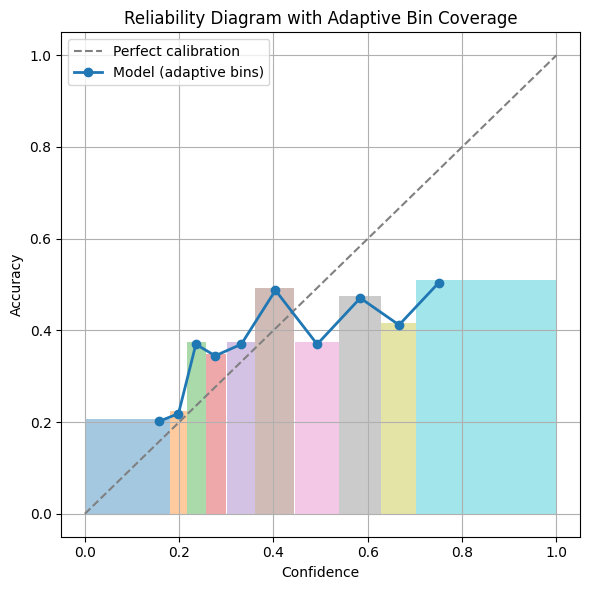

ECE on calibrated answer (test data): 0.11343862116336823


In [13]:
print(
    f"ECE on calibrated answer (test data): {calculate_ece_adaptive_bins(calibrated_test_answers_probs, test_data['targets'], verbose=True)}"
)

tensor([9.9886e-01, 1.0002e-03, 1.3908e-04, 1.6672e-06, 1.1507e-06, 1.0192e-06,
        4.1051e-07, 7.4129e-08, 7.2916e-08, 2.9681e-08, 9.1515e-09, 4.4803e-09,
        3.7689e-09, 2.2292e-09, 1.2425e-09, 1.0467e-09, 7.5897e-10, 6.3310e-10,
        5.5670e-10, 5.2531e-10])


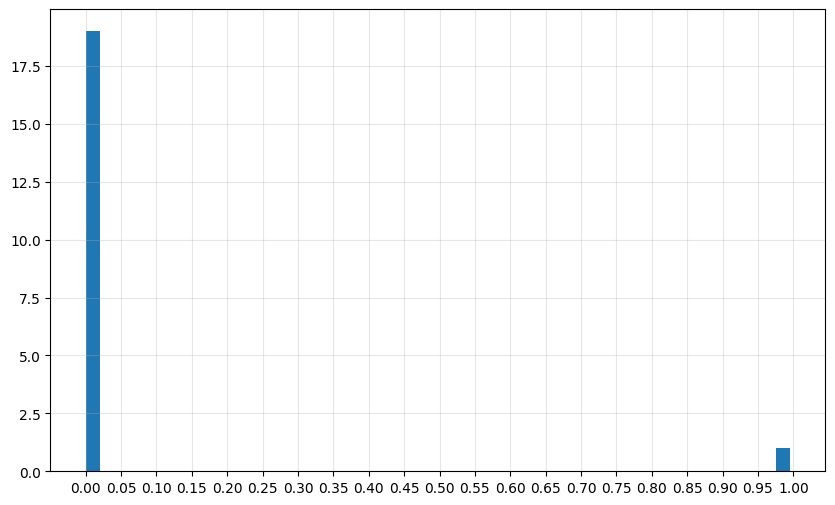

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(not_calibrated_test_answers_probs[1], bins=50)
plt.xticks(np.arange(0.0, 1.001, 5e-2))
plt.grid(True, alpha=0.3)
print(not_calibrated_test_answers_probs[8])
plt.show()

tensor([0.4844, 0.1292, 0.0886, 0.0380, 0.0354, 0.0346, 0.0291, 0.0210, 0.0209,
        0.0176, 0.0140, 0.0122, 0.0119, 0.0107, 0.0096, 0.0093, 0.0087, 0.0084,
        0.0082, 0.0081])


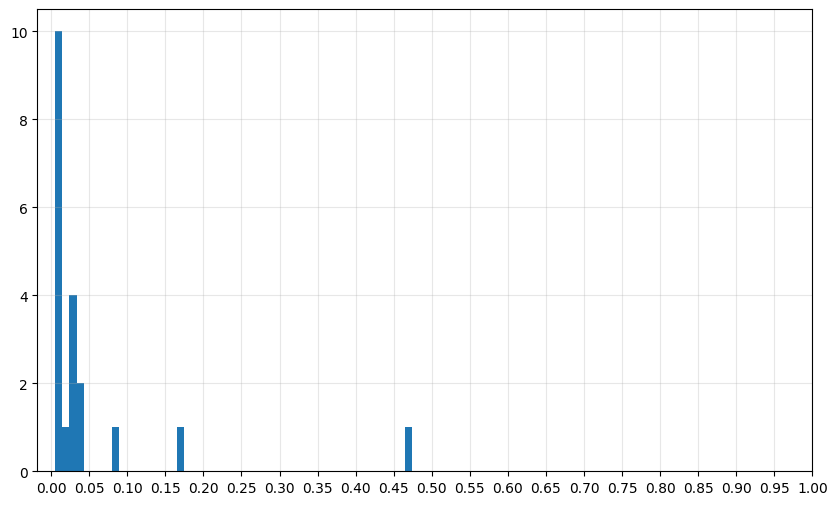

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(calibrated_test_answers_probs[1], bins=50)
plt.xticks(np.arange(0.0, 1.001, 5e-2))
plt.grid(True, alpha=0.3)
print(calibrated_test_answers_probs[8])
plt.show()

In [16]:
accuracies = (
    not_calibrated_test_answers_probs.argmax(dim=-1) == test_data["targets"]
).to(torch.float)
print(f"Accuracy on NON calibrated answer: {torch.mean(accuracies).item()}")

Accuracy on NON calibrated answer: 0.3756260573863983


In [17]:
accuracies = (
    calibrated_test_answers_probs.argmax(dim=-1) == test_data["targets"]
).to(torch.float)
print(f"Accuracy on calibrated answer: {torch.mean(accuracies).item()}")

Accuracy on calibrated answer: 0.3756260573863983
